# 00 — Phase A Orientation: data shape, sphingolipid locus, ChvI overlap

**Project**: `caulobacter_fur_lipida_loss`
**Author**: Adam Arkin (ORCID 0000-0002-4999-2931), with Kathy Ryan (UC Berkeley, krr@berkeley.edu) — data and question owner.

## Purpose

Quick, evidence-grounded look at what the colleague's data + the published mechanism tell us, before formalizing the `RESEARCH_PLAN.md`. The headline mechanism is already published — **Zik et al. 2022 *Cell Reports*** (PMID 35649364) shows lipid A is dispensable in *C. crescentus* in the absence of Fur and in the presence of anionic sphingolipids (CPG). **Uchendu et al. 2026** bioRxiv (`10.1101/2026.04.12.717747`) adds three sphingolipid IM transporter genes — CCNA_01213 (lptG2), CCNA_01214 (lptF2), CCNA_01226 (lptC2) — that share the LptB ATPase with LPS transport.

This notebook tests, against the colleague's RNA-seq (4580, 4584, 4599) and 1-replicate OM proteome:

| Hypothesis | What this notebook checks |
|---|---|
| H1 — ChvG-ChvI as cooperator vs consequence | Overlap of 4584-vs-4580 and 4599-vs-4584 DEGs with the published Stein 2021 + Quintero-Yanes 2022 ChvI regulons |
| H2 — Critical Fur regulon subset | Top up/down in 4584-vs-4580 (the "Fur-released + SspB-released" axis); known Fur-target families (TBDTs, ferritin, oxidative stress) |
| H3 — Sphingolipid substitution + transport induction | Expression and DE of the sphingolipid biosynthesis + Uchendu IM-transporter locus (CCNA_01212–01226) and CtpA/LpxE-like CCNA_03113 |
| Zik 2022 suppressor loci | Behavior of CCNA_00497, CCNA_01068 (wbqA), CCNA_01553, CCNA_03733 |
| Canonical LPS transport apparatus | Is the LptA/B/D/E/F/G apparatus *maintained* in 4599 (no LPS) — supporting Uchendu's "shared component" model? |

**This is a scoping notebook.** Findings here feed `RESEARCH_PLAN.md`. Nothing is asserted as final — figures and tables are saved for cross-reference.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 180)
sns.set_context('notebook')
sns.set_style('whitegrid')

PROJ = Path('/home/aparkin/BERIL-research-observatory/projects/caulobacter_fur_lipida_loss')
DATA_IN = Path('/home/aparkin/data/kr-caulobacter-envelope/clean')
DATA_OUT = PROJ / 'data'
FIG = PROJ / 'figures'
DATA_OUT.mkdir(exist_ok=True, parents=True)
FIG.mkdir(exist_ok=True, parents=True)

sx     = pd.read_csv(DATA_IN / 'strain_crosswalk.csv')
qc     = pd.read_csv(DATA_IN / 'sample_qc.csv')
feat   = pd.read_csv(DATA_IN / 'dim_feature.csv')
cpm    = pd.read_csv(DATA_IN / 'fact_expression_cpm.csv')
diff   = pd.read_csv(DATA_IN / 'fact_differential.csv')
prot   = pd.read_csv(DATA_IN / 'om_proteome.csv')
chvi_qy = pd.read_csv(DATA_IN / 'chvi_regulon_quintero_yanes_2022.csv')
chvi_st = pd.read_csv(DATA_IN / 'chvi_overexpression_regulon_stein_2021.csv')

print('Loaded:')
for name, df in [('strain_crosswalk', sx), ('sample_qc', qc), ('dim_feature', feat),
                 ('cpm', cpm), ('diff', diff), ('om_proteome', prot),
                 ('chvi_qy', chvi_qy), ('chvi_st', chvi_st)]:
    print(f'  {name:25s}  {df.shape}')


Loaded:
  strain_crosswalk           (3, 6)
  sample_qc                  (9, 10)
  dim_feature                (4020, 4)
  cpm                        (35613, 5)
  diff                       (11871, 8)
  om_proteome                (795, 27)
  chvi_qy                    (594, 8)
  chvi_st                    (162, 8)


## 1. Strain and library layout (sanity)


In [2]:
print('Strain crosswalk:'); display(sx)
print('\nLibrary QC (mapping percentages):')
display(qc[['sample','strain','replicate','total_reads','pct_mapped','pct_cds_of_mapped']])


Strain crosswalk:


,rnaseq_strain_id,proteome_strain_id,genotype,deletions,role,notes
0,4580,4580,rsaA::gent,rsaA,baseline (S-layer deletion),rsaA (S-layer) deleted in all strains so loss of LpxC/lipid A does not shed ...
1,4584,4659,fur::hyg sspB::spec rsaA::gent,fur;sspB;rsaA,fur/sspB mutant,"RNA-seq strain 4584 == proteome/OM strain 4659 (regrown single colony, re-sa..."
2,4599,4672,lpxC::tet fur::hyg sspB::spec rsaA::gent,lpxC;fur;sspB;rsaA,lpxC (lipid A) mutant,RNA-seq strain 4599 == proteome/OM strain 4672. Adds lpxC (lipid A / LPS bio...



Library QC (mapping percentages):


,sample,strain,replicate,total_reads,pct_mapped,pct_cds_of_mapped
0,4580_626,4580,626,24333200,96.904,40.011
1,4580_629,4580,629,26363720,96.885,40.211
2,4580_630,4580,630,22752160,97.066,40.737
3,4584_626,4584,626,23609828,96.806,40.311
4,4584_629,4584,629,22755604,96.700,40.565
5,4584_630,4584,630,18906400,96.932,40.150
6,4599_626,4599,626,21137554,96.968,39.644
7,4599_629,4599,629,21519736,96.577,39.348
8,4599_630,4599,630,20040108,96.747,38.867


## 2. DEG counts per contrast

Two thresholds: the author's "DEG" call (`|logFC| > 1` and `p < 0.05`) and a stricter `FDR < 0.05` call. Each shown per contrast and split by feature_type.


In [3]:
def deg_counts(df, lfc_thr, p_col, p_thr):
    sig = df[(df['logFC'].abs() > lfc_thr) & (df[p_col] < p_thr)]
    return (sig
            .groupby(['contrast','feature_type'])
            .agg(n_up=('logFC', lambda x: (x>0).sum()),
                 n_dn=('logFC', lambda x: (x<0).sum()))
            .reset_index())

print('|logFC|>1 AND raw p<0.05 (author cutoff):')
display(deg_counts(diff, 1, 'pvalue', 0.05))

print('\n|logFC|>1 AND FDR<0.05 (stricter):')
display(deg_counts(diff, 1, 'fdr', 0.05))

print('\n|logFC|>1.4 AND FDR<0.05 (hand-curated cutoff from "IFCI>1.4" sheet):')
display(deg_counts(diff, 1.4, 'fdr', 0.05))


|logFC|>1 AND raw p<0.05 (author cutoff):


,contrast,feature_type,n_up,n_dn
0,4584_vs_4580,CDS,113,34
1,4584_vs_4580,ncRNA,16,3
2,4599_vs_4580,CDS,412,177
3,4599_vs_4580,ncRNA,23,14
4,4599_vs_4584,CDS,231,92
5,4599_vs_4584,ncRNA,13,5



|logFC|>1 AND FDR<0.05 (stricter):


,contrast,feature_type,n_up,n_dn
0,4584_vs_4580,CDS,107,32
1,4584_vs_4580,ncRNA,12,2
2,4599_vs_4580,CDS,406,174
3,4599_vs_4580,ncRNA,23,12
4,4599_vs_4584,CDS,224,90
5,4599_vs_4584,ncRNA,11,5



|logFC|>1.4 AND FDR<0.05 (hand-curated cutoff from "IFCI>1.4" sheet):


,contrast,feature_type,n_up,n_dn
0,4584_vs_4580,CDS,72,14
1,4584_vs_4580,ncRNA,8,0
2,4599_vs_4580,CDS,253,51
3,4599_vs_4580,ncRNA,19,7
4,4599_vs_4584,CDS,112,16
5,4599_vs_4584,ncRNA,7,1


**Read:** comparing 4584-vs-4580 (Fur+SspB effect on Δ*rsaA* background) and 4599-vs-4584 (the *added*-Δ*lpxc* effect on Fur+SspB+Δ*rsaA*) is the cleanest way to attribute signals. 4599-vs-4580 is the cumulative phenotype.


## 3. Sphingolipid biosynthesis + transport locus (H3 — primary test)

Loci of interest from Zik 2022 + Olea-Ozuna 2020/2024 + **Uchendu 2026** (new transporters bolded):

| Locus | Gene / role |
|---|---|
| CCNA_01212 | *bcerS* — bacterial ceramide synthase |
| **CCNA_01213** | ***lptG2*** — sphingolipid IM transporter (Uchendu 2026) |
| **CCNA_01214** | ***lptF2*** — sphingolipid IM transporter (Uchendu 2026) |
| CCNA_01217 | sphingolipid biosynthesis (required for CHIR-090 tolerance, Zik 2022) |
| CCNA_01218 | sphingosine kinase |
| CCNA_01219 | sphingolipid biosynthesis (required, Zik 2022) |
| CCNA_01220 | *spt* — serine palmitoyltransferase |
| CCNA_01221 | *acp* — acyl carrier protein |
| CCNA_01222 | *cerR* — ceramide reductase |
| CCNA_01223 | *acps* — ACP synthetase |
| **CCNA_01226** | ***lptC2*** — sphingolipid IM transporter (Caulobacter-specific, Uchendu 2026) |
| CCNA_03113 | *ctpA* — C-terminal processing protease; LpxE-like (may substitute for LpxF) |


In [4]:
SPHINGO = ['CCNA_01212','CCNA_01213','CCNA_01214','CCNA_01217','CCNA_01218','CCNA_01219',
           'CCNA_01220','CCNA_01221','CCNA_01222','CCNA_01223','CCNA_01226','CCNA_03113']
SPHINGO_NAME = {
    'CCNA_01212':'bcerS','CCNA_01213':'lptG2 (Uchendu)','CCNA_01214':'lptF2 (Uchendu)',
    'CCNA_01217':'sphingo_01217','CCNA_01218':'sphk','CCNA_01219':'sphingo_01219',
    'CCNA_01220':'spt','CCNA_01221':'acp','CCNA_01222':'cerR','CCNA_01223':'acps',
    'CCNA_01226':'lptC2 (Uchendu)','CCNA_03113':'ctpA / LpxE-like',
}

# annotation in dim_feature
sph_feat = feat[feat['locustag'].isin(SPHINGO)][['locustag','gene','description','feature_type']]
sph_feat['role'] = sph_feat['locustag'].map(SPHINGO_NAME)
print('Annotation (dim_feature):')
display(sph_feat.sort_values('locustag'))


Annotation (dim_feature):


,locustag,gene,description,feature_type,role
1176,CCNA_01212,NaN,dATP pyrophosphohydrolase,CDS,bcerS
1177,CCNA_01213,NaN,YjgP/YjgQ family membrane permease,CDS,lptG2 (Uchendu)
1178,CCNA_01214,NaN,YjgP/YjgQ family membrane permease,CDS,lptF2 (Uchendu)
1181,CCNA_01217,NaN,phosphatidylglycerophosphate synthase,CDS,sphingo_01217
1182,CCNA_01218,NaN,sphingosine kinase/diacylglycerol kinase-related protein,CDS,sphk
1183,CCNA_01219,NaN,putative cytosolic protein,CDS,sphingo_01219
1184,CCNA_01220,ccbF,BioF-family ceramide biosynthesis protein CcbF,CDS,spt
1185,CCNA_01221,NaN,acyl carrier protein,CDS,acp
1186,CCNA_01222,NaN,NADH-ubiquinone oxidoreductase,CDS,cerR
1187,CCNA_01223,NaN,acyl-CoA synthetase,CDS,acps


In [5]:
# Mean CPM per strain
mean_cpm_strain = (cpm[cpm['locustag'].isin(SPHINGO)]
                   .groupby(['locustag','strain'])['cpm'].mean()
                   .unstack('strain'))
mean_cpm_strain = mean_cpm_strain.reindex(SPHINGO)
mean_cpm_strain['role'] = mean_cpm_strain.index.map(SPHINGO_NAME)
mean_cpm_strain = mean_cpm_strain[['role'] + [c for c in mean_cpm_strain.columns if c != 'role']]
print('Mean TMM-CPM per strain (sphingolipid + transport locus):')
display(mean_cpm_strain.round(1))

# DE: 4584-vs-4580 (Fur+SspB effect) and 4599-vs-4584 (lpxC effect)
sph_de = (diff[diff['locustag'].isin(SPHINGO) &
              diff['contrast'].isin(['4584_vs_4580','4599_vs_4584'])]
         .pivot_table(index='locustag', columns='contrast',
                      values=['logFC','fdr'], aggfunc='first'))
sph_de.columns = ['_'.join(c) for c in sph_de.columns]
sph_de = sph_de.reindex(SPHINGO)
sph_de.insert(0, 'role', sph_de.index.map(SPHINGO_NAME))
print('\nDE in 4584_vs_4580 (Fur+SspB) and 4599_vs_4584 (lpxC), sphingolipid locus:')
display(sph_de.round(2))

sph_de.to_csv(DATA_OUT / '00_sphingolipid_locus_de.csv')
mean_cpm_strain.to_csv(DATA_OUT / '00_sphingolipid_locus_cpm.csv')


Mean TMM-CPM per strain (sphingolipid + transport locus):


strain,role,4580,4584,4599
locustag,,,,
CCNA_01212,bcerS,186.6,181.3,170.8
CCNA_01213,lptG2 (Uchendu),264.7,221.8,138.1
CCNA_01214,lptF2 (Uchendu),191.1,183.0,128.2
CCNA_01217,sphingo_01217,418.5,333.2,281.4
CCNA_01218,sphk,247.0,187.7,160.2
CCNA_01219,sphingo_01219,71.8,62.4,63.2
CCNA_01220,spt,1397.8,898.0,674.0
CCNA_01221,acp,185.9,133.3,134.9
CCNA_01222,cerR,75.1,65.3,62.6



DE in 4584_vs_4580 (Fur+SspB) and 4599_vs_4584 (lpxC), sphingolipid locus:


,role,fdr_4584_vs_4580,fdr_4599_vs_4584,logFC_4584_vs_4580,logFC_4599_vs_4584
locustag,,,,,
CCNA_01212,bcerS,0.86,0.48,-0.04,-0.09
CCNA_01213,lptG2 (Uchendu),0.53,0.03,-0.25,-0.68
CCNA_01214,lptF2 (Uchendu),0.85,0.01,-0.06,-0.51
CCNA_01217,sphingo_01217,0.05,0.06,-0.33,-0.24
CCNA_01218,sphk,0.02,0.08,-0.40,-0.23
CCNA_01219,sphingo_01219,0.39,0.92,-0.20,0.02
CCNA_01220,spt,0.00,0.01,-0.64,-0.41
CCNA_01221,acp,0.08,0.94,-0.48,0.02
CCNA_01222,cerR,0.34,0.71,-0.20,-0.06


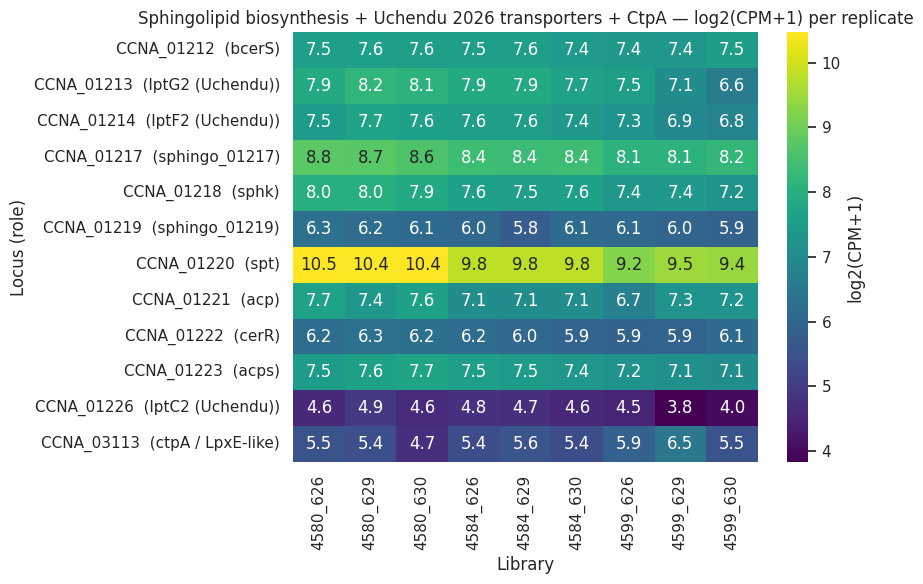

In [6]:
# Heatmap of log2(CPM+1) per replicate
sph_cpm = cpm[cpm['locustag'].isin(SPHINGO)].copy()
sph_cpm['log2cpm'] = np.log2(sph_cpm['cpm'] + 1)
mat = sph_cpm.pivot_table(index='locustag', columns='sample', values='log2cpm').reindex(SPHINGO)
sample_order = sorted(mat.columns, key=lambda s: (int(s.split('_')[0]), s))
mat = mat[sample_order]
yticks = [f'{lt}  ({SPHINGO_NAME[lt]})' for lt in mat.index]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(mat, cmap='viridis', annot=mat.round(1), fmt='.1f', cbar_kws={'label':'log2(CPM+1)'},
            yticklabels=yticks, xticklabels=sample_order, ax=ax)
ax.set_title('Sphingolipid biosynthesis + Uchendu 2026 transporters + CtpA — log2(CPM+1) per replicate')
ax.set_xlabel('Library')
ax.set_ylabel('Locus (role)')
plt.tight_layout()
plt.savefig(FIG / '00_sphingolipid_locus_heatmap.png', dpi=140, bbox_inches='tight')
plt.show()


## 4. Canonical LPS transport apparatus — is it maintained in 4599?

Uchendu 2026 explicitly suggests sphingolipid transport may *share* downstream Lpt components with LPS transport (no sphingolipid-specific LptA/D/E found). If true, the canonical LptA/B/D/E should remain expressed in 4599 (Δ*lpxc*) despite no LPS substrate. Search by gene name and description in `dim_feature`.


In [7]:
# heuristic search — Lpt naming in Caulobacter NA1000 annotation may not match E. coli exactly
mask = (feat['gene'].fillna('').str.match(r'^lpt[a-zA-Z]?$', case=False) |
        feat['description'].fillna('').str.contains(r'\bLpt[A-G]\b|lipopolysaccharide.{0,30}(transport|export|assembly)', case=False, regex=True))
lpt_candidates = feat[mask][['locustag','gene','description','feature_type']]
print(f'Lpt candidates (heuristic): {len(lpt_candidates)}')
display(lpt_candidates.sort_values('gene'))


Lpt candidates (heuristic): 6


/tmp/ipykernel_46895/2721181456.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  feat['description'].fillna('').str.contains(r'\bLpt[A-G]\b|lipopolysaccharide.{0,30}(transport|export|assembly)', case=False, regex=True))


,locustag,gene,description,feature_type
303,CCNA_00307,NaN,phospholipid-lipopolysaccharide ABC transporter,CDS
1704,CCNA_01760,NaN,LPS assembly outer membrane protein LptD,CDS
1705,CCNA_01761,NaN,LPS export ABC transporter permease LptG,CDS
1706,CCNA_01762,NaN,LPS export ABC transporter permease LptF,CDS
3605,CCNA_03716,NaN,LptC-related lipopolysaccharide assembly protein,CDS
3753,CCNA_03866,NaN,LptE superfamily protein,CDS


In [8]:
if len(lpt_candidates) > 0:
    lpt_loci = lpt_candidates['locustag'].tolist()
    lpt_cpm = (cpm[cpm['locustag'].isin(lpt_loci)]
               .groupby(['locustag','strain'])['cpm'].mean()
               .unstack('strain'))
    lpt_cpm = lpt_cpm.merge(lpt_candidates[['locustag','gene','description']].set_index('locustag'),
                             left_index=True, right_index=True)
    lpt_de = (diff[diff['locustag'].isin(lpt_loci) &
                  diff['contrast'].isin(['4584_vs_4580','4599_vs_4584'])]
              .pivot_table(index='locustag', columns='contrast', values=['logFC','fdr'], aggfunc='first'))
    lpt_de.columns = ['_'.join(c) for c in lpt_de.columns]
    print('Canonical Lpt apparatus — mean CPM:')
    display(lpt_cpm.round(1))
    print('\nCanonical Lpt apparatus — DE:')
    display(lpt_de.round(2))
    lpt_cpm.to_csv(DATA_OUT / '00_lpt_apparatus_cpm.csv')
    lpt_de.to_csv(DATA_OUT / '00_lpt_apparatus_de.csv')
else:
    print('No canonical Lpt candidates by gene name / description — need protein-homology lookup (defer to NB01).')


Canonical Lpt apparatus — mean CPM:


,4580,4584,4599,gene,description
locustag,,,,,
CCNA_00307,132.4,139.8,259.9,NaN,phospholipid-lipopolysaccharide ABC transporter
CCNA_01760,432.5,436.7,486.8,NaN,LPS assembly outer membrane protein LptD
CCNA_01761,172.7,153.7,176.3,NaN,LPS export ABC transporter permease LptG
CCNA_01762,262.9,233.0,258.1,NaN,LPS export ABC transporter permease LptF
CCNA_03716,64.7,83.7,123.1,NaN,LptC-related lipopolysaccharide assembly protein
CCNA_03866,195.0,228.6,211.7,NaN,LptE superfamily protein



Canonical Lpt apparatus — DE:


,fdr_4584_vs_4580,fdr_4599_vs_4584,logFC_4584_vs_4580,logFC_4599_vs_4584
locustag,,,,
CCNA_00307,0.88,0.01,0.08,0.89
CCNA_01760,0.96,0.20,0.01,0.16
CCNA_01761,0.47,0.21,-0.17,0.20
CCNA_01762,0.46,0.35,-0.17,0.15
CCNA_03716,0.08,0.00,0.37,0.56
CCNA_03866,0.16,0.35,0.23,-0.11


## 5. ChvI envelope-stress regulon overlap (H1)

Two reference sets:
- **Stein 2021** (`chvi_overexpression_regulon_stein_2021.csv`) — 162 ChvI overexpression-induced genes
- **Quintero-Yanes 2022** (`chvi_regulon_quintero_yanes_2022.csv`) — 594 entries, two directions (`down_in_delta_chvI` = ChvI-induced; `up_in_delta_chvI` = ChvI-repressed)

If ChvI is a **permissive condition** for Δ*lpxc*, we expect ChvI-induced genes to be enriched in 4584-vs-4580 up-DEGs (induced *before* Δ*lpxc* is added). If ChvI is a **downstream consequence**, the enrichment should appear in 4599-vs-4584 instead.


In [9]:
# Normalize Stein regulon to CCNA where possible; drop the 24 gene-symbol-only rows for set ops
stein_ccna = chvi_st[chvi_st['locus_or_gene'].fillna('').str.startswith('CCNA_')]['locus_or_gene'].tolist()
stein_set = set(stein_ccna)
print(f'Stein 2021 ChvI overexpression set (CCNA-keyed): {len(stein_set)} of {len(chvi_st)} total')

qy_induced = set(chvi_qy[chvi_qy['direction']=='down_in_delta_chvI']['gene_id'])
qy_repressed = set(chvi_qy[chvi_qy['direction']=='up_in_delta_chvI']['gene_id'])
print(f'Quintero-Yanes 2022 ChvI-induced set: {len(qy_induced)}')
print(f'Quintero-Yanes 2022 ChvI-repressed set: {len(qy_repressed)}')

# Our up-DEG sets at |logFC|>1, FDR<0.05
def deg_set(contrast, direction='up', lfc_thr=1.0, fdr_thr=0.05):
    sub = diff[(diff['contrast']==contrast) &
               (diff['logFC'].abs() > lfc_thr) &
               (diff['fdr'] < fdr_thr)]
    if direction == 'up':
        return set(sub[sub['logFC']>0]['locustag'])
    return set(sub[sub['logFC']<0]['locustag'])

up_4584 = deg_set('4584_vs_4580', 'up')
dn_4584 = deg_set('4584_vs_4580', 'dn')
up_4599_v_4584 = deg_set('4599_vs_4584', 'up')
dn_4599_v_4584 = deg_set('4599_vs_4584', 'dn')

print(f'\nUp in 4584_vs_4580 (Fur+SspB released): {len(up_4584)}')
print(f'Down in 4584_vs_4580: {len(dn_4584)}')
print(f'Up in 4599_vs_4584 (added Δlpxc): {len(up_4599_v_4584)}')
print(f'Down in 4599_vs_4584: {len(dn_4599_v_4584)}')


Stein 2021 ChvI overexpression set (CCNA-keyed): 137 of 162 total
Quintero-Yanes 2022 ChvI-induced set: 301
Quintero-Yanes 2022 ChvI-repressed set: 293

Up in 4584_vs_4580 (Fur+SspB released): 119
Down in 4584_vs_4580: 34
Up in 4599_vs_4584 (added Δlpxc): 235
Down in 4599_vs_4584: 95


In [10]:
from scipy.stats import hypergeom

# universe: tested CDS+ncRNA loci in fact_differential
universe = set(diff['locustag'].unique())
N = len(universe)
print(f'Universe (tested loci): N={N}')

def enrich(deg, regulon, label):
    deg = deg & universe
    regulon = regulon & universe
    overlap = deg & regulon
    K, n = len(regulon), len(deg)
    k = len(overlap)
    # P(X >= k) under hypergeometric
    p = hypergeom.sf(k-1, N, K, n) if k > 0 else 1.0
    expected = K * n / N if N else 0
    return dict(label=label, regulon_size=K, deg_size=n, overlap=k, expected=round(expected,1),
                fold=round((k / expected) if expected else float('nan'), 2),
                p=p)

rows = []
for deg, deg_name in [(up_4584, 'Up in 4584_vs_4580'),
                       (dn_4584, 'Down in 4584_vs_4580'),
                       (up_4599_v_4584, 'Up in 4599_vs_4584'),
                       (dn_4599_v_4584, 'Down in 4599_vs_4584')]:
    rows.append(enrich(deg, stein_set, f'{deg_name} ∩ Stein ChvI-induced'))
    rows.append(enrich(deg, qy_induced, f'{deg_name} ∩ QY ChvI-induced'))
    rows.append(enrich(deg, qy_repressed, f'{deg_name} ∩ QY ChvI-repressed'))

enrich_df = pd.DataFrame(rows)
enrich_df['p'] = enrich_df['p'].apply(lambda x: f'{x:.2e}')
print('\nHypergeometric enrichment of ChvI regulons in our DEG sets:')
display(enrich_df)
enrich_df.to_csv(DATA_OUT / '00_chvi_enrichment.csv', index=False)


Universe (tested loci): N=3957

Hypergeometric enrichment of ChvI regulons in our DEG sets:


,label,regulon_size,deg_size,overlap,expected,fold,p
0,Up in 4584_vs_4580 ∩ Stein ChvI-induced,133,119,19,4.0,4.75,8.05e-09
1,Up in 4584_vs_4580 ∩ QY ChvI-induced,293,119,28,8.8,3.18,1.82e-08
2,Up in 4584_vs_4580 ∩ QY ChvI-repressed,291,119,7,8.8,0.80,7.84e-01
3,Down in 4584_vs_4580 ∩ Stein ChvI-induced,133,34,2,1.1,1.75,3.18e-01
4,Down in 4584_vs_4580 ∩ QY ChvI-induced,293,34,1,2.5,0.40,9.28e-01
5,Down in 4584_vs_4580 ∩ QY ChvI-repressed,291,34,2,2.5,0.80,7.26e-01
6,Up in 4599_vs_4584 ∩ Stein ChvI-induced,133,235,36,7.9,4.56,1.44e-15
7,Up in 4599_vs_4584 ∩ QY ChvI-induced,293,235,50,17.4,2.87,1.40e-12
8,Up in 4599_vs_4584 ∩ QY ChvI-repressed,291,235,16,17.3,0.93,6.67e-01
9,Down in 4599_vs_4584 ∩ Stein ChvI-induced,133,95,2,3.2,0.63,8.36e-01


## 6. Zik 2022 suppressor loci behavior

Zik et al. 2022 identified suppressors of LpxC essentiality:
- Δ*fur* (already in 4584/4599)
- ΔCCNA_00497 (S-LPS biosynthesis)
- ΔCCNA_01068 (*wbqA* — S-LPS)
- ΔCCNA_01553 (S-LPS-related)
- ΔCCNA_03733 (*manC*-like — sugar biosynthesis)

These are *alternative* suppressor routes. We don't expect them to be differentially expressed (they were genetically deleted in Zik's other strains, not regulated). But the check is cheap.


In [11]:
SUPPRESSORS = ['CCNA_00497','CCNA_01068','CCNA_01553','CCNA_03733']
sup_feat = feat[feat['locustag'].isin(SUPPRESSORS)][['locustag','gene','description']]
print('Annotation (suppressor loci):')
display(sup_feat)

sup_cpm = (cpm[cpm['locustag'].isin(SUPPRESSORS)]
           .groupby(['locustag','strain'])['cpm'].mean()
           .unstack('strain').reindex(SUPPRESSORS))
print('\nMean CPM per strain:')
display(sup_cpm.round(1))

sup_de = (diff[diff['locustag'].isin(SUPPRESSORS)]
          .pivot_table(index='locustag', columns='contrast', values=['logFC','fdr'], aggfunc='first'))
sup_de.columns = ['_'.join(c) for c in sup_de.columns]
print('\nDE behavior:')
display(sup_de.round(2))
sup_de.to_csv(DATA_OUT / '00_zik_suppressors_de.csv')


Annotation (suppressor loci):


,locustag,gene,description
488,CCNA_00497,NaN,smooth LPS biosynthesis glycosyltransferase
1037,CCNA_01068,NaN,glycosyltransferase
1503,CCNA_01553,NaN,WcaJ-family glycosyltransferase
3621,CCNA_03733,NaN,mannose-1-phosphate guanylyltransferase



Mean CPM per strain:


strain,4580,4584,4599
locustag,,,
CCNA_00497,381.1,312.9,260.1
CCNA_01068,114.9,105.3,89.4
CCNA_01553,58.7,47.6,52.2
CCNA_03733,185.7,185.2,200.4



DE behavior:


,fdr_4584_vs_4580,fdr_4599_vs_4580,fdr_4599_vs_4584,logFC_4584_vs_4580,logFC_4599_vs_4580,logFC_4599_vs_4584
locustag,,,,,,
CCNA_00497,0.18,0.00,0.09,-0.28,-0.55,-0.27
CCNA_01068,0.54,0.01,0.10,-0.13,-0.36,-0.24
CCNA_01553,0.16,0.26,0.40,-0.30,-0.17,0.13
CCNA_03733,0.99,0.41,0.41,-0.00,0.11,0.11


## 7. Top up/down in 4599-vs-4584 — the *added*-Δ*lpxc* signature

This contrast isolates the transcriptional response to lipid-A loss on the already-Δfur Δsspb Δrsaa background. The strongest signal here is the "what does the cell do when it can no longer make lipid A" response.


In [12]:
def topn(contrast, n=25):
    sub = diff[(diff['contrast']==contrast) & (diff['fdr'] < 0.05)].copy()
    sub = sub.merge(feat[['locustag','gene','description']], on='locustag', how='left')
    sub_up = sub[sub['logFC']>0].nlargest(n, 'logFC')[['locustag','gene','description','logFC','fdr','feature_type']]
    sub_dn = sub[sub['logFC']<0].nsmallest(n, 'logFC')[['locustag','gene','description','logFC','fdr','feature_type']]
    return sub_up, sub_dn

up25, dn25 = topn('4599_vs_4584', 25)
print(f'TOP 25 UP in 4599_vs_4584 (lipid-A-loss response):')
display(up25.reset_index(drop=True))
print(f'\nTOP 25 DOWN in 4599_vs_4584:')
display(dn25.reset_index(drop=True))
up25.to_csv(DATA_OUT / '00_top25_up_4599_vs_4584.csv', index=False)
dn25.to_csv(DATA_OUT / '00_top25_dn_4599_vs_4584.csv', index=False)


TOP 25 UP in 4599_vs_4584 (lipid-A-loss response):


,locustag,gene,description,logFC,fdr,feature_type
0,CCNA_02517,NaN,RcnB family protein,4.517696,0.000025,CDS
1,CCNA_02205,NaN,RcnB family protein,4.420999,0.000009,CDS
2,CCNA_03327,NaN,hypothetical protein,3.884544,0.000082,CDS
3,CCNA_02378,NaN,SIMPL family protein,3.874556,0.000076,CDS
4,CCNA_03169,NaN,SH3 domain protein,3.868726,0.000159,CDS
5,CCNA_03487,NaN,"zonular occludens toxin, zot-like protein",3.857214,0.000009,CDS
6,CCNA_R0184,NaN,NaN,3.773363,0.000015,ncRNA
7,CCNA_01361,NaN,PepSY superfamily protein,3.768517,0.000033,CDS
8,CCNA_01075,NaN,beta/gamma crystallin family protein,3.611622,0.000003,CDS
9,CCNA_01362,urpR,two-component response regulator UrpR,3.377279,0.000006,CDS



TOP 25 DOWN in 4599_vs_4584:


,locustag,gene,description,logFC,fdr,feature_type
0,CCNA_02788,NaN,Xre-family transcriptional regulator,-2.398584,0.000105,CDS
1,CCNA_00427,NaN,hypothetical protein,-2.394932,0.005727,CDS
2,CCNA_R0148,NaN,NaN,-1.881834,0.009458,ncRNA
3,CCNA_03915,NaN,hypothetical protein,-1.861848,0.006196,CDS
4,CCNA_03218,NaN,periplasmic multidrug efflux lipoprotein precursor,-1.826563,0.001444,CDS
5,CCNA_02638,NaN,CLC voltage-gated chloride channel,-1.712824,0.000757,CDS
6,CCNA_03229,NaN,FAD dependent oxidoreductase,-1.699446,0.000232,CDS
7,CCNA_03230,glnA2,glutamine synthetase,-1.644673,0.000172,CDS
8,CCNA_02282,NaN,VanZ family protein,-1.556039,0.003228,CDS
9,CCNA_02529,dprA,"DNA recombination-mediator protein A, SMF family",-1.540242,0.028716,CDS


In [13]:
# Same for 4584-vs-4580 (Fur+SspB release signature)
up25b, dn25b = topn('4584_vs_4580', 25)
print(f'TOP 25 UP in 4584_vs_4580 (Fur+SspB release):')
display(up25b.reset_index(drop=True))
print(f'\nTOP 25 DOWN in 4584_vs_4580:')
display(dn25b.reset_index(drop=True))
up25b.to_csv(DATA_OUT / '00_top25_up_4584_vs_4580.csv', index=False)
dn25b.to_csv(DATA_OUT / '00_top25_dn_4584_vs_4580.csv', index=False)


TOP 25 UP in 4584_vs_4580 (Fur+SspB release):


,locustag,gene,description,logFC,fdr,feature_type
0,CCNA_02277,hutA,TonB-dependent outer membrane channel HutA,10.510821,6.676913e-10,CDS
1,CCNA_02275,NaN,DUF4198 domain-containing protein,9.847587,9.778952e-09,CDS
2,CCNA_02794,NaN,lasso peptide isopeptide bond-forming cyclase,8.601769,9.097781e-11,CDS
3,CCNA_R0158,NaN,NaN,8.374005,1.337285e-10,ncRNA
4,CCNA_02274,NaN,EF-Hand domain protein,8.265150,1.339354e-09,CDS
5,CCNA_03904,NaN,hypothetical protein,7.424133,9.818341e-09,CDS
6,CCNA_03365,NaN,hypothetical protein,6.854481,1.145391e-10,CDS
7,CCNA_02869,NaN,GTA-gp10 phage tail tube protein,5.714557,2.430178e-07,CDS
8,CCNA_R0183,NaN,NaN,4.509436,3.540468e-07,ncRNA
9,CCNA_R0097,NaN,NaN,4.403156,2.470957e-05,ncRNA



TOP 25 DOWN in 4584_vs_4580:


,locustag,gene,description,logFC,fdr,feature_type
0,CCNA_02188,NaN,PaaI-family thioesterase,-4.411331,7.570828e-08,CDS
1,CCNA_00055,NaN,ferric uptake regulation protein,-4.085965,4.008802e-08,CDS
2,CCNA_02189,NaN,"peptidase, C13 family",-2.618966,2.325397e-05,CDS
3,CCNA_02743,NaN,TonB dependent receptor,-1.921445,4.233093e-03,CDS
4,CCNA_03644,sdhC,succinate dehydrogenase cytochrome b556 subunit,-1.734002,3.761314e-05,CDS
5,CCNA_03108,chvT,TonB-dependent outer membrane receptor ChvT,-1.730037,3.143158e-03,CDS
6,CCNA_03643,NaN,succinate dehydrogenase membrane anchor subunit,-1.718340,1.489069e-06,CDS
7,CCNA_02033,nuoA,NADH-quinone oxidoreductase chain A,-1.627552,8.007009e-06,CDS
8,CCNA_02742,NaN,hypothetical protein,-1.625199,7.018986e-05,CDS
9,CCNA_02032,nuoB,NADH-quinone oxidoreductase chain B,-1.538695,3.507305e-05,CDS


## 8. OM proteome — sphingolipid pathway, Lpt apparatus, suppressor loci

One replicate per strain → no statistics, only direction. Treat as "detected at all" vs "abundance ranking."

Mapping: abundance_4580 = baseline; abundance_4659 = 4584 (Fur+SspB-rsaA); abundance_4672 = 4599 (Δlpxc).


In [14]:
# How many proteins detected per strain?
det_counts = {'4580 (rsaA)': prot['abundance_4580'].notna().sum(),
              '4659 (=4584, +fur sspB)': prot['abundance_4659'].notna().sum(),
              '4672 (=4599, +lpxC)': prot['abundance_4672'].notna().sum()}
print('OM proteins detected (non-NA abundance):')
for k,v in det_counts.items():
    print(f'  {k:30s}  {v}')

# Sphingolipid pathway in OM proteome
sph_prot = prot[prot['ccna_locus'].isin(SPHINGO)]
print(f'\nSphingolipid locus in OM proteome: {len(sph_prot)} hits')
display(sph_prot[['ccna_locus','gene_symbol','description','abundance_4580','abundance_4659','abundance_4672']])

# Zik suppressors in OM
sup_prot = prot[prot['ccna_locus'].isin(SUPPRESSORS)]
print(f'\nZik suppressor loci in OM proteome: {len(sup_prot)} hits')
display(sup_prot[['ccna_locus','gene_symbol','description','abundance_4580','abundance_4659','abundance_4672']])

# Lpt by gene name
if len(lpt_candidates) > 0:
    lpt_prot = prot[prot['ccna_locus'].isin(lpt_candidates['locustag'])]
    print(f'\nCanonical Lpt candidates in OM proteome: {len(lpt_prot)} hits')
    display(lpt_prot[['ccna_locus','gene_symbol','description','abundance_4580','abundance_4659','abundance_4672']])


OM proteins detected (non-NA abundance):
  4580 (rsaA)                     468
  4659 (=4584, +fur sspB)         516
  4672 (=4599, +lpxC)             582

Sphingolipid locus in OM proteome: 4 hits


,ccna_locus,gene_symbol,description,abundance_4580,abundance_4659,abundance_4672
395,CCNA_01217,NaN,submitted name: Phosphatidylglycerophosphate synthase [OS=Caulobacter vibrio...,82.0,80.6,137.5
526,CCNA_01226,NaN,LPS export ABC transporter periplasmic protein LptC [OS=Caulobacter vibrioid...,90.2,67.3,142.5
592,CCNA_01223,NaN,Putative acyl-CoA synthetase CCNA_01223 [OS=Caulobacter vibrioides NA1000],NaN,NaN,NaN
778,CCNA_01212,bcerS,Bacterial ceramide synthase [OS=Caulobacter vibrioides NA1000],NaN,NaN,NaN



Zik suppressor loci in OM proteome: 1 hits


,ccna_locus,gene_symbol,description,abundance_4580,abundance_4659,abundance_4672
667,CCNA_00497,NaN,submitted name: Rhamnosyl transferase [OS=Caulobacter vibrioides NA1000],NaN,NaN,NaN



Canonical Lpt candidates in OM proteome: 4 hits


,ccna_locus,gene_symbol,description,abundance_4580,abundance_4659,abundance_4672
34,CCNA_01760,lptD,LPS-assembly protein LptD [OS=Caulobacter vibrioides NA1000],117.4,106.0,76.6
156,CCNA_03866,NaN,submitted name: LptE superfamily protein [OS=Caulobacter vibrioides NA1000],111.3,119.3,69.4
315,CCNA_00307,NaN,submitted name: Phospholipid-lipopolysaccharide ABC transporter [OS=Caulobac...,NaN,NaN,300.0
720,CCNA_01762,NaN,submitted name: YjgP/YjgQ family membrane permease [OS=Caulobacter vibrioide...,NaN,NaN,NaN


In [15]:
# Strain abundance shift for proteins detected in all 3 strains
all3 = prot.dropna(subset=['abundance_4580','abundance_4659','abundance_4672']).copy()
all3['log2_4659_over_4580'] = np.log2(all3['abundance_4659'] / all3['abundance_4580'])
all3['log2_4672_over_4659'] = np.log2(all3['abundance_4672'] / all3['abundance_4659'])
print(f'Proteins detected in all 3 strains: {len(all3)}')

# Top 15 up/down by 4659/4580 (Fur+SspB-rsaA effect at the OM)
print('\nTOP 15 UP in 4659 (Fur+SspB release) vs 4580:')
display(all3.nlargest(15, 'log2_4659_over_4580')[['ccna_locus','gene_symbol','description','log2_4659_over_4580']])
print('\nTOP 15 UP in 4672 (added Δlpxc) vs 4659:')
display(all3.nlargest(15, 'log2_4672_over_4659')[['ccna_locus','gene_symbol','description','log2_4672_over_4659']])
print('\nTOP 15 DOWN in 4672 vs 4659:')
display(all3.nsmallest(15, 'log2_4672_over_4659')[['ccna_locus','gene_symbol','description','log2_4672_over_4659']])

all3.to_csv(DATA_OUT / '00_om_proteome_strain_shifts.csv', index=False)


Proteins detected in all 3 strains: 429

TOP 15 UP in 4659 (Fur+SspB release) vs 4580:


,ccna_locus,gene_symbol,description,log2_4659_over_4580
114,CCNA_02275,NaN,"submitted name: ABC transporter, periplasmic component [OS=Caulobacter vibri...",8.908393
120,CCNA_00778,bipA,Large ribosomal subunit assembly factor BipA [OS=Caulobacter vibrioides NA1000],6.309328
6,CCNA_00028,NaN,submitted name: TonB-dependent receptor [OS=Caulobacter vibrioides NA1000],5.567802
220,CCNA_02623,ftsZ,Cell division protein FtsZ [OS=Caulobacter vibrioides NA1000],4.772072
211,CCNA_01770,ndk,Nucleoside diphosphate kinase [OS=Caulobacter vibrioides NA1000],3.884523
364,CCNA_03156,NaN,submitted name: Periplasmic protein [OS=Caulobacter vibrioides NA1000],3.843274
200,CCNA_01805,NaN,Dihydrolipoyl dehydrogenase [OS=Caulobacter vibrioides NA1000],3.807979
240,CCNA_01086,lepA,Elongation factor 4 [OS=Caulobacter vibrioides NA1000],3.484070
298,CCNA_03711,hpf,Ribosome hibernation promoting factor [OS=Caulobacter vibrioides NA1000],3.428635
3,CCNA_03023,NaN,submitted name: TonB-dependent receptor [OS=Caulobacter vibrioides NA1000],3.413302



TOP 15 UP in 4672 (added Δlpxc) vs 4659:


,ccna_locus,gene_symbol,description,log2_4672_over_4659
188,CCNA_00698,NaN,DUF3617 domain-containing protein [OS=Caulobacter vibrioides NA1000],8.738092
725,CCNA_00369,NaN,submitted name: Magnesium and cobalt efflux protein corC-like protein [OS=Ca...,6.698457
481,CCNA_00025,NaN,submitted name: Major facilitator superfamily transporter [OS=Caulobacter vi...,6.478625
224,CCNA_01252,sdpA,submitted name: Soluble lytic murein transglycosylase SdpA [OS=Caulobacter v...,4.819918
48,CCNA_01386,NaN,17 kDa surface antigen [OS=Caulobacter vibrioides NA1000],4.747745
314,CCNA_02986,NaN,submitted name: Uncharacterized protein [OS=Caulobacter vibrioides NA1000],4.651249
30,CCNA_03169,NaN,submitted name: SH3 domain protein [OS=Caulobacter vibrioides NA1000],4.515006
190,CCNA_02517,NaN,submitted name: Uncharacterized protein [OS=Caulobacter vibrioides NA1000],4.366195
306,CCNA_03563,atpH,ATP synthase subunit delta [OS=Caulobacter vibrioides NA1000],3.846704
233,CCNA_00800,cydA,"submitted name: Cytochrome bd-type quinol oxidase, subunit 1 cydA [OS=Caulob...",3.773996



TOP 15 DOWN in 4672 vs 4659:


,ccna_locus,gene_symbol,description,log2_4672_over_4659
299,CCNA_03384,rpmE,Large ribosomal subunit protein bL31 [OS=Caulobacter vibrioides NA1000],-5.661966
115,CCNA_00357,NaN,submitted name: Secretory tripeptidyl aminopeptidase [OS=Caulobacter vibrioi...,-5.152919
694,CCNA_01792,rpmF,Large ribosomal subunit protein bL32 [OS=Caulobacter vibrioides NA1000],-4.972080
88,CCNA_01306,rplC,Large ribosomal subunit protein uL3 [OS=Caulobacter vibrioides NA1000],-4.327020
161,CCNA_01317,rplX,Large ribosomal subunit protein uL24 [OS=Caulobacter vibrioides NA1000],-4.317017
323,CCNA_01325,rplO,Large ribosomal subunit protein uL15 [OS=Caulobacter vibrioides NA1000],-4.222635
252,CCNA_01313,rplP,Large ribosomal subunit protein uL16 [OS=Caulobacter vibrioides NA1000],-3.696686
230,CCNA_00321,rplU,Large ribosomal subunit protein bL21 [OS=Caulobacter vibrioides NA1000],-3.685466
545,NaN,NaN,SWISS-PROT:P00766 Chymotrypsinogen A - Bos taurus (Bovine).,-3.388271
407,CCNA_01654,NaN,peptidylprolyl isomerase [OS=Caulobacter vibrioides NA1000],-3.315687


## 9. Summary — what the data says before formalizing the plan

A compact text summary cell. The actual *finding* (whether sphingolipid locus is induced, whether ChvI overlap is significant, etc.) depends on the executed numbers above. This cell is meant to be read alongside the printed tables.


In [16]:
print('=== EVIDENCE SUMMARY ===\n')

# H1: ChvI overlap
ch_enriched = pd.read_csv(DATA_OUT / '00_chvi_enrichment.csv')
ch_4584_up_qy = ch_enriched[ch_enriched['label']=='Up in 4584_vs_4580 ∩ QY ChvI-induced'].iloc[0]
ch_4599_up_qy = ch_enriched[ch_enriched['label']=='Up in 4599_vs_4584 ∩ QY ChvI-induced'].iloc[0]
print('H1 — ChvI overlap with our DEGs (QY ChvI-induced set):')
print(f'  Up in 4584_vs_4580 (Fur+SspB release):  fold={ch_4584_up_qy["fold"]}, p={ch_4584_up_qy["p"]}, overlap={ch_4584_up_qy["overlap"]}/{ch_4584_up_qy["regulon_size"]}')
print(f'  Up in 4599_vs_4584 (added Δlpxc):       fold={ch_4599_up_qy["fold"]}, p={ch_4599_up_qy["p"]}, overlap={ch_4599_up_qy["overlap"]}/{ch_4599_up_qy["regulon_size"]}')
print('  Interpretation: If enrichment is in 4584_vs_4580, ChvI is a PERMISSIVE condition (induced before Δlpxc).')
print('                  If only in 4599_vs_4584, ChvI is a DOWNSTREAM CONSEQUENCE of lipid-A loss.')

# H3: sphingolipid locus
sph_de_df = pd.read_csv(DATA_OUT / '00_sphingolipid_locus_de.csv')
print('\nH3 — Sphingolipid locus DE (logFC; positive = induced):')
print(sph_de_df[['locustag','role','logFC_4584_vs_4580','logFC_4599_vs_4584']].round(2).to_string(index=False))

# How many sphingolipid loci significantly up in each contrast?
sph_up_4584 = (sph_de_df['logFC_4584_vs_4580'] > 0) & (sph_de_df['fdr_4584_vs_4580'] < 0.05)
sph_up_4599v4584 = (sph_de_df['logFC_4599_vs_4584'] > 0) & (sph_de_df['fdr_4599_vs_4584'] < 0.05)
print(f'\nSphingolipid loci significantly UP (FDR<0.05):')
print(f'  in 4584_vs_4580 (Fur+SspB):    {sph_up_4584.sum()}/{len(sph_de_df)}')
print(f'  in 4599_vs_4584 (added Δlpxc): {sph_up_4599v4584.sum()}/{len(sph_de_df)}')

print('\n=== End summary. See tables above and figures/, data/ for full output. ===')


=== EVIDENCE SUMMARY ===

H1 — ChvI overlap with our DEGs (QY ChvI-induced set):
  Up in 4584_vs_4580 (Fur+SspB release):  fold=3.18, p=1.82e-08, overlap=28/293
  Up in 4599_vs_4584 (added Δlpxc):       fold=2.87, p=1.4e-12, overlap=50/293
  Interpretation: If enrichment is in 4584_vs_4580, ChvI is a PERMISSIVE condition (induced before Δlpxc).
                  If only in 4599_vs_4584, ChvI is a DOWNSTREAM CONSEQUENCE of lipid-A loss.

H3 — Sphingolipid locus DE (logFC; positive = induced):
  locustag             role  logFC_4584_vs_4580  logFC_4599_vs_4584
CCNA_01212            bcerS               -0.04               -0.09
CCNA_01213  lptG2 (Uchendu)               -0.25               -0.68
CCNA_01214  lptF2 (Uchendu)               -0.06               -0.51
CCNA_01217    sphingo_01217               -0.33               -0.24
CCNA_01218             sphk               -0.40               -0.23
CCNA_01219    sphingo_01219               -0.20                0.02
CCNA_01220              spt

## Outputs

Saved to `projects/caulobacter_fur_lipida_loss/data/`:
- `00_sphingolipid_locus_cpm.csv`, `00_sphingolipid_locus_de.csv`
- `00_lpt_apparatus_cpm.csv`, `00_lpt_apparatus_de.csv` (if found by heuristic)
- `00_chvi_enrichment.csv`
- `00_zik_suppressors_de.csv`
- `00_top25_up_4599_vs_4584.csv`, `00_top25_dn_4599_vs_4584.csv`
- `00_top25_up_4584_vs_4580.csv`, `00_top25_dn_4584_vs_4580.csv`
- `00_om_proteome_strain_shifts.csv`

Saved to `figures/`:
- `00_sphingolipid_locus_heatmap.png`

These feed the `RESEARCH_PLAN.md` "Expected Outcomes" section and disambiguate which hypotheses warrant primary vs secondary analysis status.
